# Exploratory Data Analysis

Before performing the processing of data and the training of the model, we need to give a look to which kind of data we have and which analysis we need to perform.

In [ ]:
# import libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('../data/raw/telco_churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info() # By looking at the info there are no missing values

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [ ]:
# now I split the categorical and numerical variables to see the carachteristic of eaach group of variables
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')  # è il target

In [ ]:
print(df['TotalCharges'])
df.iloc[(df['TotalCharges']==" ").tolist(),]
# we can see that total charge is a numerical variable but it is consider an object because for 11 rows
# we have that the value is a space
# for all this missing values we have tenure equal to 0 so they probably are new and haven't paid yet

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [95]:
nan_index=(df['TotalCharges']==" ").tolist()

In [97]:
df.loc[(df['TotalCharges']==" ").tolist(), 'TotalCharges'] = np.nan
df['TotalCharges']= df['TotalCharges'].astype(dtype='float64')
df.loc[nan_index, 'TotalCharges']=np.nan


In [98]:
print(df['TotalCharges'].dtype)
print(sum(nan_index))

float64
11


11
      MonthlyCharges  TotalCharges
488            52.55           NaN
753            20.25           NaN
936            80.85           NaN
1082           25.75           NaN
1340           56.05           NaN
3331           19.85           NaN
3826           25.35           NaN
4380           20.00           NaN
5218           19.70           NaN
6670           73.35           NaN
6754           61.90           NaN
            0  TotalCharges
0       29.85         29.85
1     1936.30       1889.50
2      107.70        108.15
3     1903.50       1840.75
4      141.40        151.65
...       ...           ...
7038  2035.20       1990.50
7039  7430.40       7362.90
7040   325.60        346.45
7041   297.60        306.60
7042  6972.90       6844.50

[7032 rows x 2 columns]
[[1.         0.99955986]
 [0.99955986 1.        ]]


<Axes: >

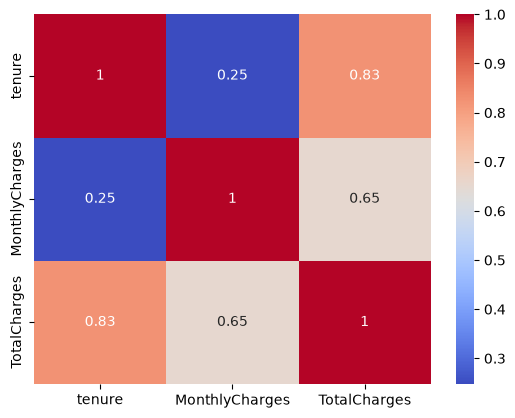

In [133]:
# I want to check if there is a  mathematical relation between the Monthly Charges and the total Charges
print(df.shape[0] - sum(df['MonthlyCharges']<=df['TotalCharges'])) # 11 value where total not large than month
print(df.loc[[not x for x in ((df['MonthlyCharges']<=df['TotalCharges'])).to_list()], ['MonthlyCharges', 'TotalCharges']])
# the monthly charges are larger than the total only when we have a NaN
# so this two variables are consistent

# Now let's check the variable that could affect the total cost and let's see if there is a mathematical relation between
# the two

df.columns # tenure is the number of months the costumer has stayed with the company. So tenure*MonthlyCarghes=TotalCharges
df_charges = pd.concat([df['MonthlyCharges']*df['tenure'], df['TotalCharges']], axis=1).iloc[[not x for x in nan_index],]
print(df_charges)
print(np.corrcoef(df_charges, rowvar=False))
# They are not exactly the same but they have a correlation of 0.9996, so instead of imputing this missing value 
# we could just remove the TptalCharges variable because it doesn't add any information to the monthly charges and tenure
# variable. Otherwise we can consider the total charges equal to 0 for this people with tenure = 0
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

614


(array([4.000e+00, 2.000e+00, 1.000e+01, 1.600e+01, 4.800e+01, 8.700e+01,
        1.850e+02, 3.650e+02, 7.200e+02, 1.691e+03, 2.371e+03, 8.070e+02,
        3.620e+02, 1.930e+02, 9.400e+01, 4.200e+01, 1.900e+01, 8.000e+00,
        2.000e+00, 6.000e+00]),
 array([-373.25 , -336.045, -298.84 , -261.635, -224.43 , -187.225,
        -150.02 , -112.815,  -75.61 ,  -38.405,   -1.2  ,   36.005,
          73.21 ,  110.415,  147.62 ,  184.825,  222.03 ,  259.235,
         296.44 ,  333.645,  370.85 ]),
 <BarContainer object of 20 artists>)

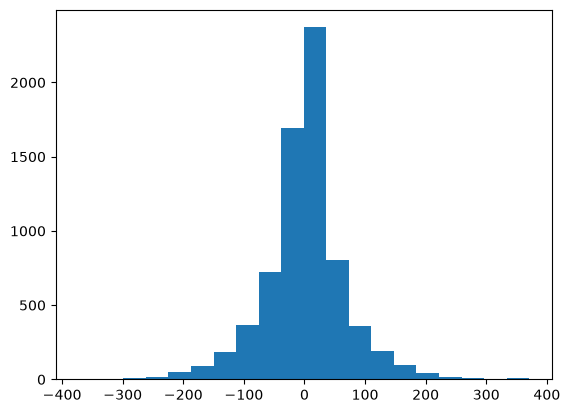

In [ ]:
print(sum(df_charges[0]==df_charges['TotalCharges']))
plt.hist(df_charges[0]-df_charges['TotalCharges'], bins=20, density=False)

In [ ]:
# Give a look to the target variable
df['Churn'].value_counts(normalize=True)
# we have that the classes are ot balanced 73% of NO and 27% of Yes

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [122]:
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [ ]:
for col in categorical_cols:
    print(col, df[col].nunique(), df[col].unique())
# as a categorical variables we also have senior Citizen which assumes only values 0 or 1
# these variables are basaically Yes or No but for some of the  we also have 'No phone service' or 'No internet service'
# we should decide if we want to keep them as a categories or to join them to the category 'No'

gender 2 <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner 2 <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents 2 <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService 2 <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines 3 <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService 3 <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity 3 <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup 3 <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection 3 <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport 3 <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV 3 <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies 3 <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract 3 <StringArray>
['Month-to-month', 

In [ ]:
for col in ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'SeniorCitizen']:
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    print(churn_rate, '\n')

# we can see there are some group of people with a higher chance of churn, for example who has month to month contract,
# Fiber optic, who pays with electronic check and senior citizen

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64 

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64 

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64 

gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64 

SeniorCitizen
0    0.236062
1    0.416813
Name: Churn, dtype: float64 



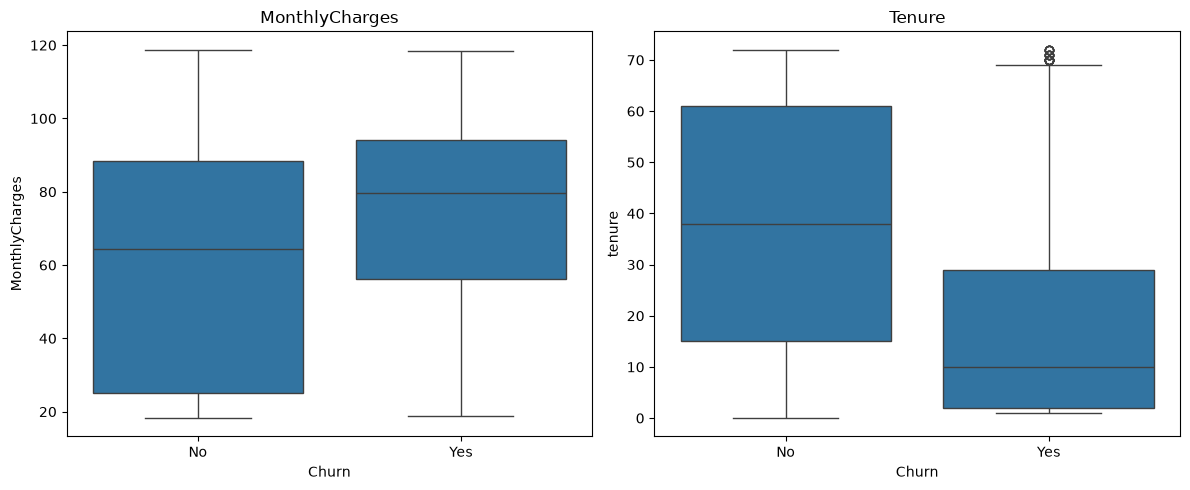

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax1)
ax1.set_title('MonthlyCharges')

sns.boxplot(data=df, x='Churn', y='tenure', ax=ax2)
ax2.set_title("Tenure")

plt.tight_layout()
plt.show()


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

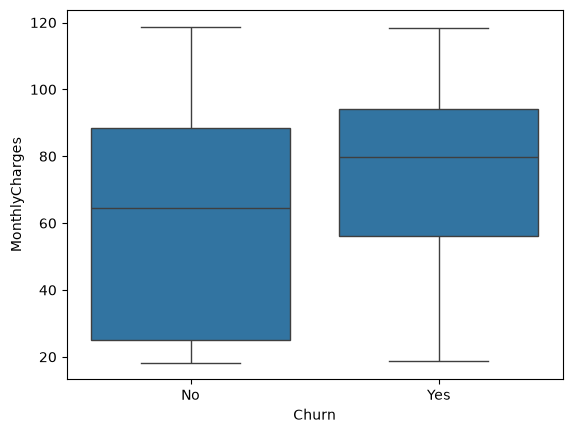

In [129]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')